In [5]:
import zipfile
import os

# Path to your zip file
zip_path = "archive (3).zip"

# Folder to extract files
extract_path = "archive_extracted"

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully to:", extract_path)

Unzipped successfully to: archive_extracted


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization, Dropout

In [6]:
from tensorflow import keras

# Training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory="archive_extracted/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

# Validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory="archive_extracted/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


### **Normalization**

In [7]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

### **Lets define our custom architecture**

In [8]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 254, 254, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 125, 125, 64)      256       
 chNormalization)                                                
                                                        

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10


10/10 [==============================] - 23s 2s/step - loss: 0.8679 - accuracy: 0.9082 - val_loss: 8.4644 - val_accuracy: 0.5361
Epoch 2/10
10/10 [==============================] - 22s 2s/step - loss: 1.3739 - accuracy: 0.9150 - val_loss: 6.3211 - val_accuracy: 0.6082
Epoch 3/10
10/10 [==============================] - 21s 2s/step - loss: 1.1616 - accuracy: 0.8844 - val_loss: 6.1693 - val_accuracy: 0.6289
Epoch 4/10
10/10 [==============================] - 22s 2s/step - loss: 0.7596 - accuracy: 0.9116 - val_loss: 4.5981 - val_accuracy: 0.5670
Epoch 5/10
10/10 [==============================] - 22s 2s/step - loss: 1.0137 - accuracy: 0.9082 - val_loss: 5.2104 - val_accuracy: 0.6082
Epoch 6/10
10/10 [==============================] - 22s 2s/step - loss: 0.8731 - accuracy: 0.9218 - val_loss: 3.3521 - val_accuracy: 0.6186
Epoch 7/10
10/10 [==============================] - 22s 2s/step - loss: 1.1366 - accuracy: 0.9320 - val_loss: 8.0691 - val_accuracy: 0.5464
Epoch 8/10
10/10 [=============

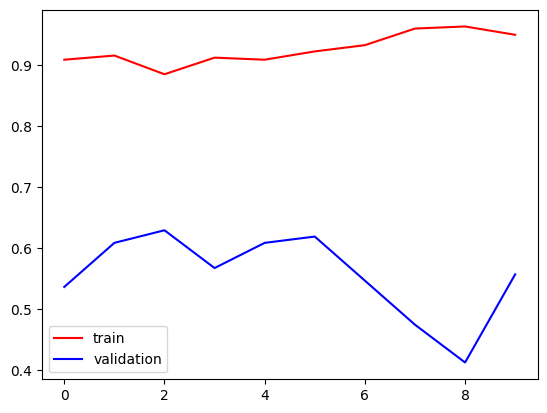

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

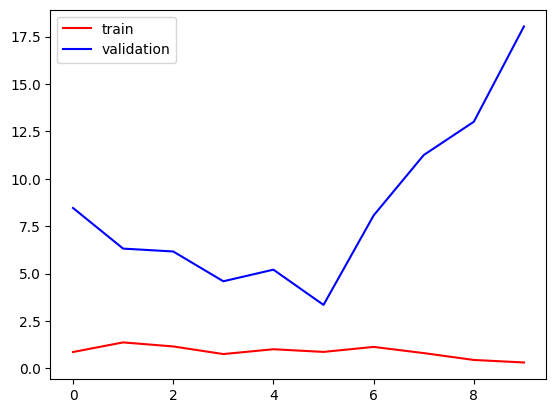

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

### **Inference**

In [15]:
import cv2

test_img = cv2.imread("archive_extracted/train/apples/img_p3_56.jpeg")

print(test_img)


[[[ 86  70  88]
  [ 82  69  85]
  [ 93  80  96]
  ...
  [ 70  71  81]
  [ 78  79  89]
  [ 91  90 100]]

 [[ 78  68  85]
  [ 76  66  83]
  [ 85  78  93]
  ...
  [ 67  68  78]
  [ 75  76  86]
  [ 87  86  96]]

 [[ 68  68  84]
  [ 67  67  83]
  [ 75  78  92]
  ...
  [ 60  62  72]
  [ 69  70  80]
  [ 81  80  90]]

 ...

 [[ 23 125 148]
  [ 21 123 145]
  [ 20 121 143]
  ...
  [ 58  55  57]
  [ 58  55  57]
  [ 46  42  47]]

 [[ 24 124 148]
  [ 22 121 143]
  [ 19 118 140]
  ...
  [ 68  63  65]
  [ 51  46  48]
  [ 28  23  25]]

 [[ 26 119 144]
  [ 28 122 145]
  [ 25 115 139]
  ...
  [ 49  42  47]
  [ 38  31  34]
  [ 18  12  13]]]


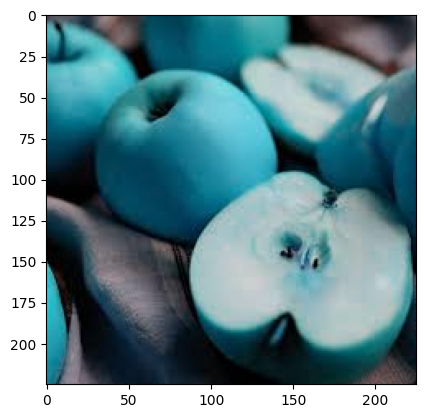

In [16]:
plt.imshow(test_img)

In [17]:
test_img.shape

(225, 225, 3)

In [18]:
test_img = cv2.resize(test_img,(256,256))

In [19]:
test_img.shape
     

(256, 256, 3)

In [20]:
test_input = test_img.reshape((1,256,256,3))

In [21]:
result = model.predict(test_input)
result

1/1 [==============================] - 0s 279ms/step


array([[0.]], dtype=float32)

In [ ]:
if int(result[0][0]) == 0:
  print("Apple")

else:
  print("Tomato")

Apple


In [23]:
print("The End")

The End
